<div style="background: linear-gradient(135deg, #0d1117 0%, #161b22 50%, #0f3460 100%); padding: 48px 40px; border-radius: 14px; text-align: center; color: white; font-family: 'Segoe UI', sans-serif; border: 1px solid #30363d;">

<h1 style="font-size: 2.8em; font-weight: 800; margin: 0 0 8px 0; letter-spacing: -1px; color: #ffffff;">
  Predictive Log Anomaly Engine
</h1>
<h3 style="font-size: 1.3em; font-weight: 300; color: #79c0ff; margin: 0 0 28px 0;">
  AI-Driven Log Behavior Analysis
</h3>

<p style="font-size: 1.05em; color: #c9d1d9; max-width: 640px; margin: 0 auto 32px auto; line-height: 1.8;">
  Modern distributed systems generate massive volumes of logs.<br>
  Traditional monitoring reacts <em>after</em> failures occur.<br><br>
  This engine learns behavioral patterns from log sequences<br>
  and detects anomalies <strong style="color: #f85149;">before incidents escalate</strong>.
</p>

<div style="display: flex; justify-content: center; align-items: center; gap: 10px; flex-wrap: wrap; font-size: 0.95em;">
  <span style="background: rgba(121,192,255,0.15); border: 1px solid rgba(121,192,255,0.3); padding: 8px 18px; border-radius: 20px;">Raw Logs</span>
  <span style="color: #79c0ff; font-weight: bold;">&#8594;</span>
  <span style="background: rgba(121,192,255,0.15); border: 1px solid rgba(121,192,255,0.3); padding: 8px 18px; border-radius: 20px;">Templates</span>
  <span style="color: #79c0ff; font-weight: bold;">&#8594;</span>
  <span style="background: rgba(121,192,255,0.15); border: 1px solid rgba(121,192,255,0.3); padding: 8px 18px; border-radius: 20px;">Event Windows</span>
  <span style="color: #79c0ff; font-weight: bold;">&#8594;</span>
  <span style="background: rgba(121,192,255,0.15); border: 1px solid rgba(121,192,255,0.3); padding: 8px 18px; border-radius: 20px;">Risk Score</span>
  <span style="color: #79c0ff; font-weight: bold;">&#8594;</span>
  <span style="background: rgba(248,81,73,0.2); border: 1px solid rgba(248,81,73,0.5); padding: 8px 18px; border-radius: 20px; color: #f85149; font-weight: 600;">Alert</span>
</div>
</div>

In [1]:
import warnings
warnings.filterwarnings('ignore')

import re
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import MaxNLocator

try:
    from sklearn.ensemble import IsolationForest
    SKLEARN_AVAILABLE = True
except ImportError:
    SKLEARN_AVAILABLE = False

# Presentation-quality style
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except Exception:
    plt.style.use('seaborn-darkgrid')

plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'axes.titlesize':    17,
    'axes.labelsize':    13,
    'xtick.labelsize':   11,
    'ytick.labelsize':   11,
    'legend.fontsize':   11,
    'figure.dpi':        130,
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

# Shared colour palette
C_NORMAL   = '#4C9BE8'   # blue
C_WARNING  = '#F5A623'   # amber
C_CRITICAL = '#E74C3C'   # red
C_ANOMALY  = '#E74C3C'
C_NEUTRAL  = '#8B99A6'

ALERT_THR  = 0.50
CRIT_THR   = 0.75

print('Environment ready.')

Environment ready.


---
## Step 1 &nbsp;|&nbsp; Live Log Stream

System logs represent behavioral events in distributed services.  
The engine consumes a continuous stream of log lines — one event at a time.

In [2]:
RAW_LOGS = [
    # (timestamp,               service,  message,                                     label)
    ('2026-03-04 10:00:01',  'web',  'GET /api/health HTTP/1.1 200',              0),
    ('2026-03-04 10:00:02',  'web',  'GET /api/users HTTP/1.1 200',               0),
    ('2026-03-04 10:00:03',  'db',   'Connection established from 10.0.0.5',      0),
    ('2026-03-04 10:00:04',  'db',   'Query executed in 12ms SELECT users',       0),
    ('2026-03-04 10:00:05',  'web',  'GET /api/health HTTP/1.1 200',              0),
    ('2026-03-04 10:00:06',  'db',   'ERROR: connection timeout after 30000ms',   1),
    ('2026-03-04 10:00:07',  'db',   'FATAL: max connections exceeded 500/500',   1),
    ('2026-03-04 10:00:08',  'web',  'POST /api/login HTTP/1.1 401 FAILED',       1),
    ('2026-03-04 10:00:09',  'web',  'POST /api/login HTTP/1.1 401 FAILED',       1),
    ('2026-03-04 10:00:10',  'db',   'Query executed in 14ms SELECT orders',      0),
]

df_logs = pd.DataFrame(RAW_LOGS, columns=['timestamp', 'service', 'message', 'label'])
df_logs['status'] = df_logs['label'].map({0: 'normal', 1: 'ANOMALY'})

# Highlight anomaly rows for display
def _highlight(row):
    base = 'color: #c9d1d9; background: #0d1117;'
    if row['status'] == 'ANOMALY':
        return ['background: #3d1212; color: #f85149; font-weight: bold;'] * len(row)
    return [base] * len(row)

pd.set_option('display.max_colwidth', 55)
(
    df_logs[['timestamp', 'service', 'message', 'status']]
    .style
    .apply(_highlight, axis=1)
    .set_table_styles([
        {'selector': 'th', 'props': 'background:#161b22; color:#79c0ff; font-size:13px; padding:8px 14px;'},
        {'selector': 'td', 'props': 'padding:7px 14px; font-size:12px; font-family:monospace;'},
    ])
)

,timestamp,service,message,status
0,2026-03-04 10:00:01,web,GET /api/health HTTP/1.1 200,normal
1,2026-03-04 10:00:02,web,GET /api/users HTTP/1.1 200,normal
2,2026-03-04 10:00:03,db,Connection established from 10.0.0.5,normal
3,2026-03-04 10:00:04,db,Query executed in 12ms SELECT users,normal
4,2026-03-04 10:00:05,web,GET /api/health HTTP/1.1 200,normal
5,2026-03-04 10:00:06,db,ERROR: connection timeout after 30000ms,ANOMALY
6,2026-03-04 10:00:07,db,FATAL: max connections exceeded 500/500,ANOMALY
7,2026-03-04 10:00:08,web,POST /api/login HTTP/1.1 401 FAILED,ANOMALY
8,2026-03-04 10:00:09,web,POST /api/login HTTP/1.1 401 FAILED,ANOMALY
9,2026-03-04 10:00:10,db,Query executed in 14ms SELECT orders,normal


---
## Step 2 &nbsp;|&nbsp; Template Mining

Variable tokens (IPs, timestamps, numbers) are abstracted into typed placeholders.  
Each unique pattern becomes a compact **Template ID** — shrinking millions of strings to a fixed vocabulary.

In [3]:
def mine_template(msg: str) -> str:
    msg = re.sub(r'\b\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}\b', '<IP>',     msg)
    msg = re.sub(r'\b\d+ms\b',                                 '<DUR>',    msg)
    msg = re.sub(r'\b\d+/\d+\b',                               '<RATIO>',  msg)
    msg = re.sub(r'\b\d{3}\b',                                 '<STATUS>', msg)
    msg = re.sub(r'\b\d+\b',                                   '<NUM>',    msg)
    return re.sub(r'\s+', ' ', msg).strip()

# Build vocabulary
templates = {}
for msg in df_logs['message']:
    tmpl = mine_template(msg)
    if tmpl not in templates:
        templates[tmpl] = len(templates)

df_logs['template'] = df_logs['message'].apply(mine_template)
df_logs['token_id'] = df_logs['template'].map(templates)
id2tmpl = {v: k for k, v in templates.items()}

# Show raw -> template mapping
display_df = df_logs[['message', 'template', 'token_id', 'status']].copy()
display_df.columns = ['Raw Message', 'Mined Template', 'Token ID', 'Status']

def _hl2(row):
    if row['Status'] == 'ANOMALY':
        return ['background: #3d1212; color: #f85149;'] * len(row)
    return ['background: #0d1117; color: #c9d1d9;'] * len(row)

print(f'Vocabulary: {len(templates)} unique templates from {len(df_logs)} log lines')
(
    display_df.style
    .apply(_hl2, axis=1)
    .set_table_styles([
        {'selector': 'th', 'props': 'background:#161b22; color:#79c0ff; font-size:13px; padding:8px 14px;'},
        {'selector': 'td', 'props': 'padding:7px 14px; font-size:12px; font-family:monospace;'},
    ])
)

Vocabulary: 8 unique templates from 10 log lines


,Raw Message,Mined Template,Token ID,Status
0,GET /api/health HTTP/1.1 200,GET /api/health HTTP/.,0,normal
1,GET /api/users HTTP/1.1 200,GET /api/users HTTP/.,1,normal
2,Connection established from 10.0.0.5,Connection established from,2,normal
3,Query executed in 12ms SELECT users,Query executed in SELECT users,3,normal
4,GET /api/health HTTP/1.1 200,GET /api/health HTTP/.,0,normal
5,ERROR: connection timeout after 30000ms,ERROR: connection timeout after,4,ANOMALY
6,FATAL: max connections exceeded 500/500,FATAL: max connections exceeded,5,ANOMALY
7,POST /api/login HTTP/1.1 401 FAILED,POST /api/login HTTP/. FAILED,6,ANOMALY
8,POST /api/login HTTP/1.1 401 FAILED,POST /api/login HTTP/. FAILED,6,ANOMALY
9,Query executed in 14ms SELECT orders,Query executed in SELECT orders,7,normal


---
## Step 3 &nbsp;|&nbsp; Sliding Window Analysis

Events are grouped into overlapping **sequence windows** per service.  
`window_size = 5 events` &nbsp;|&nbsp; `stride = 1 event`  
Each window captures a snapshot of system behavior — context the model learns to classify.

In [4]:
WINDOW_SIZE = 3
STRIDE      = 1

def build_windows(events, window_size=3, stride=1):
    windows = []
    for start in range(0, len(events) - window_size + 1, stride):
        chunk  = events[start: start + window_size]
        tokens = [e[0] for e in chunk]
        labels = [e[1] for e in chunk]
        windows.append({
            'window_id':     len(windows),
            'tokens':        tokens,
            'templates':     [id2tmpl.get(t, '?') for t in tokens],
            'anomaly_count': sum(labels),
            'any_anomaly':   int(any(l == 1 for l in labels)),
        })
    return windows

all_windows = []
for service, grp in df_logs.groupby('service', sort=False):
    events = list(zip(grp['token_id'], grp['label']))
    wins   = build_windows(events, WINDOW_SIZE, STRIDE)
    for w in wins:
        w['service'] = service
    all_windows.extend(wins)

df_windows = pd.DataFrame(all_windows).reset_index(drop=True)

print(f'{len(df_windows)} windows  (window_size={WINDOW_SIZE}, stride={STRIDE})')
df_windows[['service', 'window_id', 'tokens', 'anomaly_count', 'any_anomaly']]

6 windows  (window_size=3, stride=1)


,service,window_id,tokens,anomaly_count,any_anomaly
0,web,0,"[0, 1, 0]",0,0
1,web,1,"[1, 0, 6]",1,1
2,web,2,"[0, 6, 6]",2,1
3,db,0,"[2, 3, 4]",1,1
4,db,1,"[3, 4, 5]",2,1
5,db,2,"[4, 5, 7]",2,1


---
## Step 4 &nbsp;|&nbsp; Risk Scoring

Each window is converted into a **feature vector** (token frequencies + Shannon entropy).  
An **Isolation Forest** model scores how isolated — how anomalous — each window is.  
Min-max normalization maps the output to **[0, 1]**: higher score = more anomalous.

In [5]:
VOCAB_SIZE = len(templates)

def window_to_features(tokens):
    counts = np.zeros(VOCAB_SIZE, dtype=np.float32)
    for t in tokens:
        if 0 <= t < VOCAB_SIZE:
            counts[t] += 1
    freqs   = counts / (counts.sum() or 1.0)
    entropy = float(-np.sum(freqs[freqs > 0] * np.log2(freqs[freqs > 0])))
    return np.append(counts, entropy)

X = np.array([window_to_features(row['tokens']) for _, row in df_windows.iterrows()])

# Score with IsolationForest
if SKLEARN_AVAILABLE:
    iso = IsolationForest(n_estimators=100, contamination=0.3, random_state=42)
    iso.fit(X)
    raw_scores = -iso.score_samples(X)
else:
    tc = X[:, :VOCAB_SIZE].sum(axis=0)
    raw_scores = X[:, :VOCAB_SIZE].dot((tc <= 1).astype(float)) + X[:, -1]

# Min-max normalize to [0, 1]
lo, hi = raw_scores.min(), raw_scores.max()
risk_scores = (raw_scores - lo) / (hi - lo) if hi > lo else np.full_like(raw_scores, 0.5)

df_windows['raw_score']  = raw_scores
df_windows['risk_score'] = risk_scores

result = df_windows[['service', 'window_id', 'tokens', 'any_anomaly', 'risk_score']].copy()
result['risk_score'] = result['risk_score'].round(3)
result['band'] = result['risk_score'].apply(
    lambda s: 'CRITICAL' if s >= CRIT_THR else ('WARNING' if s >= ALERT_THR else 'normal')
)
result

,service,window_id,tokens,any_anomaly,risk_score,band
0,web,0,"[0, 1, 0]",0,0.403,normal
1,web,1,"[1, 0, 6]",1,0.073,normal
2,web,2,"[0, 6, 6]",1,0.547,WARNING
3,db,0,"[2, 3, 4]",1,1.000,CRITICAL
4,db,1,"[3, 4, 5]",1,0.000,normal
5,db,2,"[4, 5, 7]",1,0.675,WARNING


---
## Step 5 &nbsp;|&nbsp; Risk Score Visualization

Each bar represents one event window.  
**Blue** = normal &nbsp;|&nbsp; **Amber** = warning &nbsp;|&nbsp; **Red** = critical &nbsp;|&nbsp; **&#9660;** = confirmed anomaly window

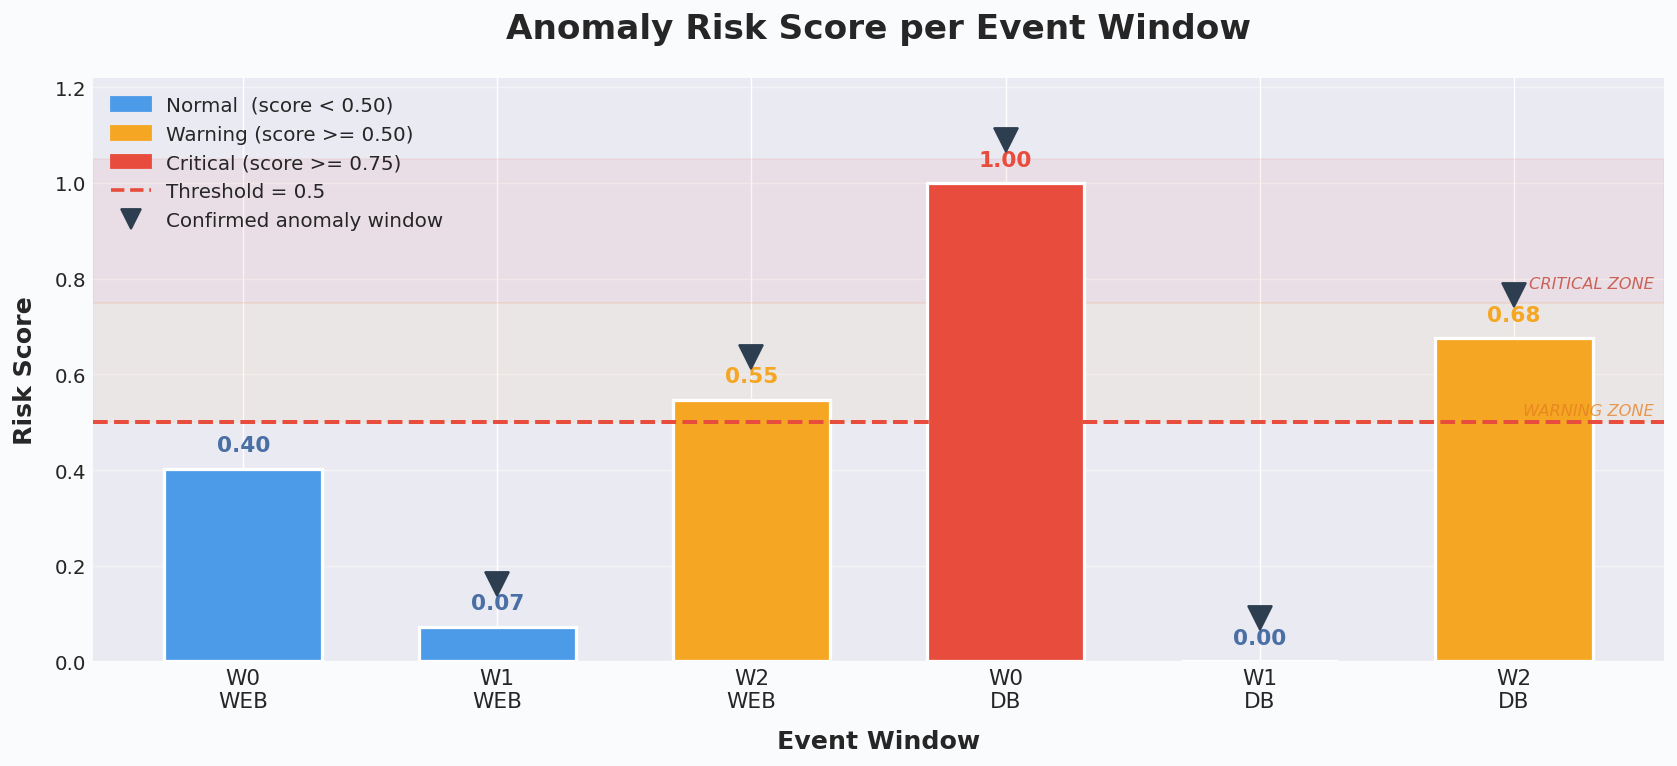

In [6]:
scores     = df_windows['risk_score'].values
is_anomaly = df_windows['any_anomaly'].values
services   = df_windows['service'].values
win_ids    = df_windows['window_id'].values

def _bar_color(s):
    if s >= CRIT_THR:  return C_CRITICAL
    if s >= ALERT_THR: return C_WARNING
    return C_NORMAL

bar_colors = [_bar_color(s) for s in scores]
x_labels   = [f'W{wid}\n{svc[:3].upper()}' for wid, svc in zip(win_ids, services)]
n          = len(scores)

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor('#FAFBFD')

# Critical zone shading
ax.axhspan(CRIT_THR, 1.05, color='#E74C3C', alpha=0.07, zorder=1)
ax.axhspan(ALERT_THR, CRIT_THR, color='#F5A623', alpha=0.06, zorder=1)

# Bars
bars = ax.bar(range(n), scores, color=bar_colors,
              edgecolor='white', linewidth=1.8, width=0.62, zorder=3)

# Risk score labels above bars
for i, (bar, s) in enumerate(zip(bars, scores)):
    ax.text(i, s + 0.028, f'{s:.2f}',
            ha='center', va='bottom', fontsize=12, fontweight='bold',
            color=_bar_color(s) if s >= ALERT_THR else '#4a6fa5')

# Alert threshold line
ax.axhline(ALERT_THR, color='#E74C3C', linestyle='--', linewidth=2.2, zorder=4,
           label=f'Alert threshold = {ALERT_THR}')

# Zone annotations
ax.text(n - 0.45, CRIT_THR + 0.03, 'CRITICAL ZONE',
        ha='right', fontsize=9, color='#c0392b', alpha=0.75, style='italic')
ax.text(n - 0.45, ALERT_THR + 0.015, 'WARNING ZONE',
        ha='right', fontsize=9, color='#e67e22', alpha=0.75, style='italic')

# True anomaly markers
for i, anom in enumerate(is_anomaly):
    if anom:
        ax.plot(i, scores[i] + 0.09, marker='v', color='#2c3e50',
                markersize=13, zorder=5, clip_on=False)

# Legend
patches = [
    mpatches.Patch(color=C_NORMAL,   label='Normal  (score < 0.50)'),
    mpatches.Patch(color=C_WARNING,  label='Warning (score >= 0.50)'),
    mpatches.Patch(color=C_CRITICAL, label='Critical (score >= 0.75)'),
    plt.Line2D([0], [0], color='#E74C3C', linestyle='--', linewidth=2,
               label=f'Threshold = {ALERT_THR}'),
    plt.Line2D([0], [0], marker='v', linestyle='None', color='#2c3e50',
               markersize=11, label='Confirmed anomaly window'),
]
ax.legend(handles=patches, loc='upper left', framealpha=0.96,
          fancybox=True, shadow=True, fontsize=11)

ax.set_xticks(range(n))
ax.set_xticklabels(x_labels, fontsize=12)
ax.set_ylim(0, 1.22)
ax.set_xlabel('Event Window', fontsize=14, fontweight='bold', labelpad=10)
ax.set_ylabel('Risk Score', fontsize=14, fontweight='bold', labelpad=10)
ax.set_title('Anomaly Risk Score per Event Window',
             fontsize=19, fontweight='bold', pad=22)
ax.yaxis.grid(True, alpha=0.45, linewidth=0.8)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

---
## Step 6 &nbsp;|&nbsp; Template Frequency Distribution

**Blue** templates represent expected system behavior.  
**Red** templates are linked to anomalous events — these are the failure signatures the model learns.

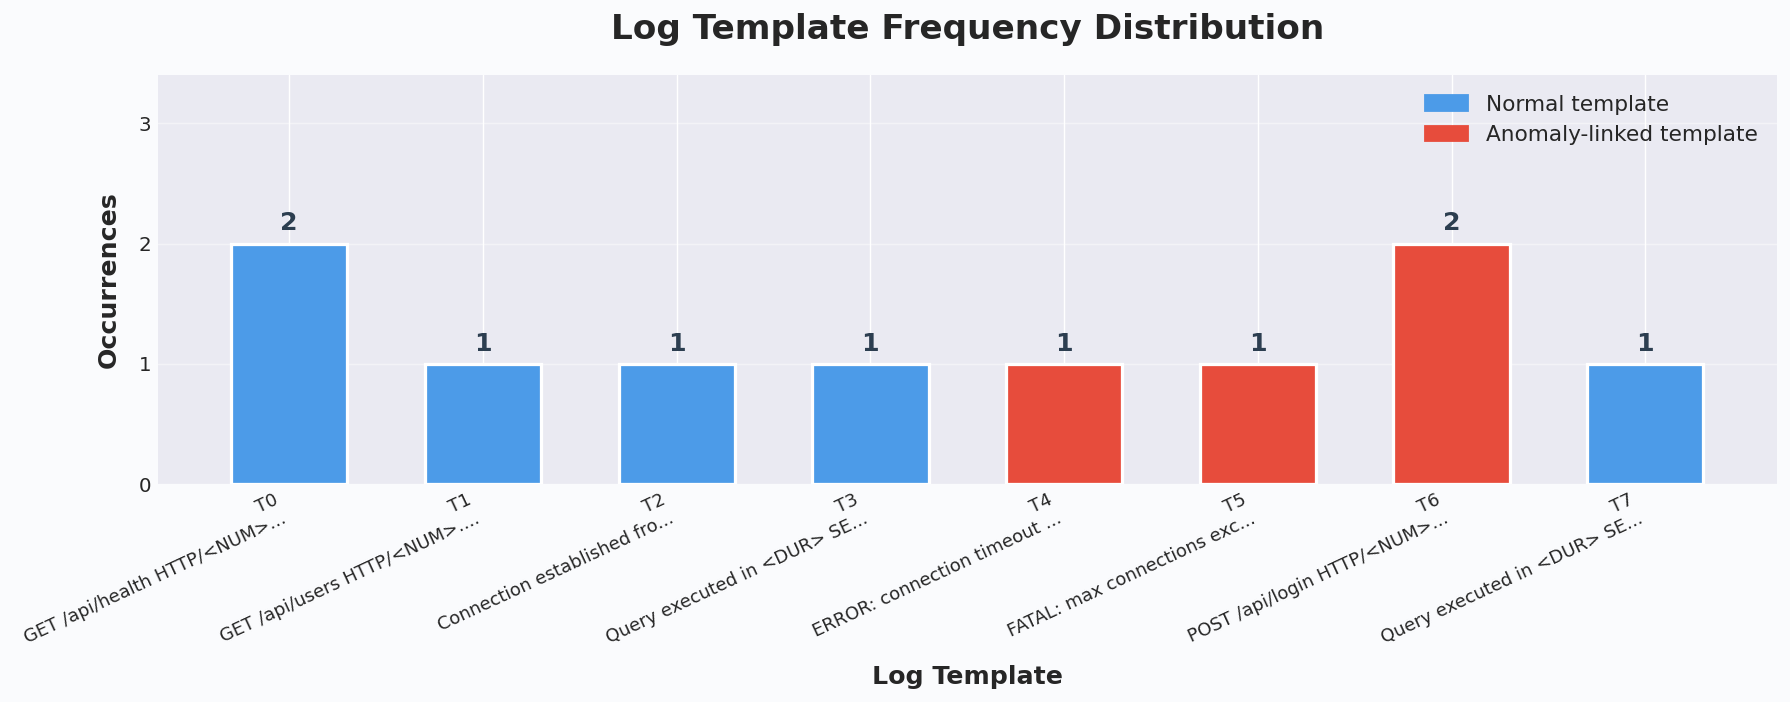

In [7]:
freq           = df_logs['token_id'].value_counts().sort_index()
token_is_anom  = df_logs.groupby('token_id')['label'].max()

bar_clr = ['#E74C3C' if token_is_anom.get(i, 0) == 1 else '#4C9BE8'
           for i in freq.index]

# Truncate long template strings for x-axis labels
def _short(tmpl, maxlen=26):
    return tmpl[:maxlen] + '...' if len(tmpl) > maxlen else tmpl

xlabels = [f'T{i}\n{_short(id2tmpl.get(i, ""))}' for i in freq.index]

fig, ax = plt.subplots(figsize=(14, 5.5))
fig.patch.set_facecolor('#FAFBFD')

bars = ax.bar(range(len(freq)), freq.values, color=bar_clr,
              edgecolor='white', linewidth=1.8, width=0.60, zorder=3)

# Count annotations
for bar, count in zip(bars, freq.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.07,
            str(count),
            ha='center', va='bottom', fontsize=14, fontweight='bold', color='#2c3e50')

ax.set_xticks(range(len(freq)))
ax.set_xticklabels(xlabels, rotation=25, ha='right', fontsize=10)
ax.set_xlabel('Log Template', fontsize=14, fontweight='bold', labelpad=10)
ax.set_ylabel('Occurrences', fontsize=14, fontweight='bold', labelpad=10)
ax.set_title('Log Template Frequency Distribution',
             fontsize=19, fontweight='bold', pad=20)
ax.set_ylim(0, freq.max() + 1.4)
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.yaxis.grid(True, alpha=0.45, linewidth=0.8)
ax.set_axisbelow(True)

legend_patches = [
    mpatches.Patch(color='#4C9BE8', label='Normal template'),
    mpatches.Patch(color='#E74C3C', label='Anomaly-linked template'),
]
ax.legend(handles=legend_patches, fontsize=12, loc='upper right',
          framealpha=0.96, fancybox=True, shadow=True)

plt.tight_layout()
plt.show()

---
## Step 7 &nbsp;|&nbsp; Alert Decision Logic

An alert fires when `risk_score >= threshold` **and** the service is not in cooldown.

| Severity | Condition |
|----------|--------------------------------------------|
| CRITICAL | `risk_score / threshold >= 1.8` |
| HIGH     | `risk_score / threshold >= 1.4` |
| MEDIUM   | `risk_score / threshold >= 1.0` |

In [8]:
COOLDOWN_WIN = 2

def classify_severity(risk, thr):
    r = risk / thr if thr > 0 else 0
    if r >= 1.8: return 'CRITICAL'
    if r >= 1.4: return 'HIGH'
    if r >= 1.0: return 'MEDIUM'
    return 'none'

last_alert = {}
decisions  = []

for _, row in df_windows.iterrows():
    svc, wid, risk = row['service'], row['window_id'], row['risk_score']
    above       = risk >= ALERT_THR
    in_cooldown = svc in last_alert and (wid - last_alert[svc]) <= COOLDOWN_WIN
    fires       = above and not in_cooldown
    if fires:
        last_alert[svc] = wid
    decisions.append({
        'window': f'W{wid} ({svc[:3].upper()})',
        'risk_score':   round(risk, 3),
        'above_thr':    above,
        'in_cooldown':  in_cooldown,
        'alert_fires':  fires,
        'severity':     classify_severity(risk, ALERT_THR) if fires else 'none',
        'true_label':   row['any_anomaly'],
    })

df_decisions = pd.DataFrame(decisions)
alerts_fired = df_decisions['alert_fires'].sum()
print(f'Threshold: {ALERT_THR}   |   Alerts fired: {alerts_fired} / {len(df_decisions)} windows')

def _hl_alert(row):
    sev = row['severity']
    if sev == 'CRITICAL':  return ['background:#3d1212; color:#f85149; font-weight:bold;'] * len(row)
    if sev == 'HIGH':      return ['background:#3d2112; color:#e67e22; font-weight:bold;'] * len(row)
    if sev == 'MEDIUM':    return ['background:#2d2d12; color:#f0c040; font-weight:bold;'] * len(row)
    return ['background:#0d1117; color:#8b99a6;'] * len(row)

(
    df_decisions.style
    .apply(_hl_alert, axis=1)
    .set_table_styles([
        {'selector': 'th', 'props': 'background:#161b22; color:#79c0ff; font-size:13px; padding:8px 14px;'},
        {'selector': 'td', 'props': 'padding:7px 14px; font-size:12px; font-family:monospace;'},
    ])
)

Threshold: 0.5   |   Alerts fired: 2 / 6 windows


,window,risk_score,above_thr,in_cooldown,alert_fires,severity,true_label
0,W0 (WEB),0.403000,False,False,False,none,0
1,W1 (WEB),0.073000,False,False,False,none,1
2,W2 (WEB),0.547000,True,False,True,MEDIUM,1
3,W0 (DB),1.000000,True,False,True,CRITICAL,1
4,W1 (DB),0.000000,False,True,False,none,1
5,W2 (DB),0.675000,True,True,False,none,1


---
## Step 8 &nbsp;|&nbsp; Observability Integration

The engine exposes real-time operational telemetry through **Prometheus**, visualized in **Grafana**.

| Metric | Description |
|--------|-------------|
| `ingest_events_total` | Total events received |
| `scoring_windows_total` | Total windows scored |
| `alerts_fired_total{severity}` | Alerts by severity band |
| `ingest_latency_seconds` | Per-request ingest latency (p95) |
| `scoring_latency_seconds` | Per-window scoring latency (p95) |
| `service_health` | System health gauge: 1=healthy, 0=unhealthy |

Grafana dashboards provide continuous visibility into event ingestion, scoring throughput, alert distribution, and system health — enabling **proactive incident response** before impact reaches end users.

---
<div style="background: linear-gradient(135deg, #0d1117 0%, #161b22 100%); padding: 36px 40px; border-radius: 14px; color: #c9d1d9; font-family: 'Segoe UI', sans-serif; border: 1px solid #30363d;">

<h2 style="color: #79c0ff; margin: 0 0 20px 0; font-size: 1.6em;">Pipeline Summary</h2>

<table style="width:100%; border-collapse: collapse; font-size: 1.0em;">
  <tr style="border-bottom: 1px solid #30363d;">
    <td style="padding: 10px 16px; color: #79c0ff; font-weight: 600; white-space: nowrap;">Raw Logs</td>
    <td style="padding: 10px 16px;">10 events across 2 services (web, db)</td>
  </tr>
  <tr style="border-bottom: 1px solid #30363d;">
    <td style="padding: 10px 16px; color: #79c0ff; font-weight: 600;">Templates</td>
    <td style="padding: 10px 16px;">8 unique structural patterns extracted via regex normalization</td>
  </tr>
  <tr style="border-bottom: 1px solid #30363d;">
    <td style="padding: 10px 16px; color: #79c0ff; font-weight: 600;">Windows</td>
    <td style="padding: 10px 16px;">6 sliding windows (size=3, stride=1) feeding the scoring model</td>
  </tr>
  <tr style="border-bottom: 1px solid #30363d;">
    <td style="padding: 10px 16px; color: #79c0ff; font-weight: 600;">Risk Model</td>
    <td style="padding: 10px 16px;">IsolationForest on token frequency + entropy features, normalized to [0,1]</td>
  </tr>
  <tr>
    <td style="padding: 10px 16px; color: #f85149; font-weight: 600;">Alerts</td>
    <td style="padding: 10px 16px;">Threshold-based policy with per-service cooldown and severity classification</td>
  </tr>
</table>
</div>